### Tutorial to learn Jupyter Notebook and how to use it for Data Analysis


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
x = np.linspace(0, 10, 500)
y = np.cumsum(np.random.randn(500, 6), 0)

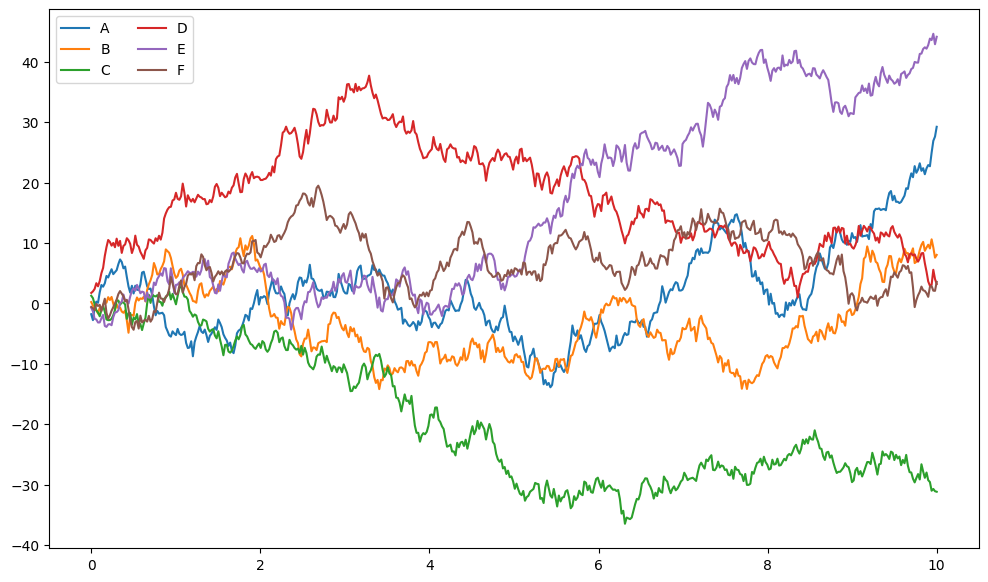

In [24]:
plt.figure(figsize=(12, 7))
plt.plot(x, y)
plt.legend("ABCDEF", ncol=2, loc="upper left")

First I'm using an external crypto API to fetch some real and bulk data to work with

In [27]:
import requests
import pandas as pd

In [38]:
def get_historic_price(symbol, exchange="bitfinex", after="2018-09-01"):
    url = "https://api.cryptowat.ch/markets/{exchange}/{symbol}usd/ohlc".format(
        symbol=symbol, exchange=exchange)
    resp = requests.get(url, params={
        "periods":"3600",
        "after": str(int(pd.Timestamp(after).timestamp()))
    })
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data['result']['3600'], columns=[
        "CloseTime", "OpenPrice", "HighPrice", "LowPrice", "ClosePrice", "Volume", "NA"
    ])
    df["CloseTime"] = pd.to_datetime(df['CloseTime'], unit='s')
    df.set_index("CloseTime", inplace=True)
    return df

In [39]:
last_week = (pd.Timestamp.now() - pd.offsets.Day(7))
last_week

Timestamp('2025-12-06 14:09:26.451810')

In [40]:
btc = get_historic_price('btc', "bitstamp", after=last_week)
eth = get_historic_price('eth', "bitstamp", after=last_week)

HTTPError: 410 Client Error: Gone for url: https://api.cryptowat.ch/markets/bitstamp/btcusd/ohlc?periods=3600&after=1765030166